# Chapter 21: Cheirality

Source orientation: printed pages 515-532; PDF pages 533-550.

This notebook gives an original computational treatment of cheirality in projective reconstructions. The source pages were used for terminology and coverage only: quasi-affine transformations, front/back camera tests, transformation effects on cheirality, the cheiral inequalities, third-view visibility, and depth ordering. No textbook prose, figures, screenshots, page crops, or exercise text are reproduced.

## Chapter Goal

A projective reconstruction may reproject every image point correctly and still place the scene on the wrong side of a camera or split the visible convex hull across the plane sent to infinity. The goal of this chapter is to make the missing orientation information executable.

By the end of the notebook, the learner should be able to compute projective depth signs, recognize quasi-affine behavior from denominator signs, formulate cheiral inequalities as linear half-space constraints, detect opposite-orientation ambiguity, classify third-view visibility from one visible anchor, and explain why depth ordering needs an orientation choice.

## Computational Translation Guide

| Book idea | Computational object in this notebook | What is checked |
| --- | --- | --- |
| Homogeneous point `X` | Length-4 NumPy vector, usually normalized to final coordinate 1 | Changing representatives does not change depth sign |
| Camera `P = [M | p_4]` | `3 x 4` array plus its center `C_P` | `P @ C_P = 0`, cofactor center matches SVD center |
| Front/back | Sign of signed projective depth | Visible synthetic points have positive depth |
| Quasi-affine transform | Last row `h4` has one sign on the point convex hull | Convex hull does not cross `h4^T X = 0` |
| Cheiral inequalities | Linear constraints `X_i^T v > 0` and `delta C_j^T v > 0` | LP margin `d` is positive when feasible |
| Third-view visibility | Compare the sign of `w_1 w_3` with one visible anchor | Predicted visibility matches direct depth sign |
| Depth ordering | Inverse depth `chi = 1 / depth` on one camera ray | Same orientation uses larger `chi`; opposite orientation reverses interpretation |

## Library Routing

| Chapter concept | Representation | Library route | Why this route |
| --- | --- | --- | --- |
| Positive depth and camera rays | Static ray/principal-plane diagrams with numeric depth labels | NumPy + Matplotlib | The geometry is a signed side test against a camera plane. |
| Quasi-affine convex hull preservation | 2D projective slice with convex hull and denominator signs | NumPy + SciPy `ConvexHull` + Matplotlib | The theorem is about a hyperplane crossing a convex hull. |
| Cheiral inequalities | Half-space feasibility cells and LP margins | SciPy `linprog` + Matplotlib | The algorithm is a linear feasibility problem. |
| Plane-at-infinity placement | Interactive 3D point/camera/plane view | Plotly | The learner can rotate the cameras, point cloud, and separating plane. |
| Sign and orientation ambiguity | Cross-section comparing separable and interleaved configurations | NumPy + Matplotlib | The ambiguity is exactly a separating-plane test. |
| Third-view visibility and depth ordering | Sign-product table plus ray-order diagram | NumPy + pandas + Matplotlib | The algebra is a sign comparison and an inverse-depth ordering. |

## Chapter-Specific Storyboard

1. **Positive depth camera rays**: show two cameras and a point set; inspect which points are in front of each principal plane.
2. **Quasi-affine convex hull signs**: compare a projective map whose denominator has one sign on the convex hull with one whose denominator changes sign.
3. **Cheiral inequality feasible cells**: solve the LP margin problem for `delta = +1` and `delta = -1`, then plot a slice of feasible `v` values.
4. **Opposite-orientation sign ambiguity**: compare a separable point/camera configuration with one where an extra camera lies among the points.
5. **Third-view visibility and depth ordering**: classify points in a third camera from `sign(w_1 w_3)`, then compare two points on one ray using inverse depth.

In [1]:
from pathlib import Path
import sys
import warnings

start = Path.cwd().resolve()
candidates = [start, *start.parents, start / "Multiple-View-Geometry-in-Computer-Vision"]
for candidate in candidates:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-21"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.optimize import linprog
from scipy.spatial import ConvexHull

from utils.artifacts import assert_artifacts, display_artifact, relative_to_book, save_csv, save_json, save_matplotlib, save_plotly_html
from utils.cameras import camera_center, camera_matrix, project_points
from utils.projective import dehomogenize, homogenize

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","axes.grid":True,"grid.alpha":0.24,"font.size":10})
warnings.filterwarnings("ignore", message="Consider using IPython.display.IFrame instead")
artifact_paths = []
check_data = {}

In [2]:
def sign_label(values, tol=1e-10):
    arr = np.asarray(values, dtype=float)
    return np.where(arr > tol, 1, np.where(arr < -tol, -1, 0))


def signed_depth(P, X):
    X = np.asarray(X, dtype=float)
    if X.shape[-1] == 3:
        X = np.r_[X, 1.0]
    M = np.asarray(P, dtype=float)[:, :3]
    y = np.asarray(P, dtype=float) @ X
    denom = X[3] * np.linalg.norm(M[2])
    if abs(denom) < 1e-12:
        return np.nan
    return float(np.sign(np.linalg.det(M)) * y[2] / denom)


def depth_signs(P, Xh):
    return sign_label([signed_depth(P, X) for X in Xh])


def image_scale(P, X):
    return float((np.asarray(P, dtype=float) @ np.asarray(X, dtype=float))[2])


def cofactor_camera_center(P):
    P = np.asarray(P, dtype=float)
    coeffs = []
    for j in range(4):
        minor = np.delete(P, j, axis=1)
        coeffs.append(((-1) ** (j + 1)) * np.linalg.det(minor))
    C = np.array(coeffs, dtype=float)
    return C / C[-1]


def make_camera(center, target, K=None):
    if K is None:
        K = np.eye(3)
    center = np.asarray(center, dtype=float)
    target = np.asarray(target, dtype=float)
    forward = target - center
    forward = forward / np.linalg.norm(forward)
    up = np.array([0.0, 1.0, 0.0])
    right = np.cross(up, forward)
    if np.linalg.norm(right) < 1e-9:
        right = np.array([1.0, 0.0, 0.0])
    right = right / np.linalg.norm(right)
    true_up = np.cross(forward, right)
    true_up = true_up / np.linalg.norm(true_up)
    R = np.vstack([right, true_up, forward])
    return camera_matrix(K, R, center)


def solve_cheiral_lp(points_h, centers_h, delta):
    rows = [np.asarray(a, dtype=float) for a in points_h]
    rows += [float(delta) * np.asarray(c, dtype=float) for c in centers_h]
    A_ub = []
    b_ub = []
    for a in rows:
        A_ub.append(np.r_[-a, 1.0])
        b_ub.append(0.0)
    result = linprog(
        c=np.array([0.0, 0.0, 0.0, 0.0, -1.0]),
        A_ub=np.asarray(A_ub),
        b_ub=np.asarray(b_ub),
        bounds=[(-1.0, 1.0)] * 4 + [(0.0, None)],
        method="highs",
    )
    if not result.success:
        return {"success": False, "delta": delta, "margin": float("nan"), "v": None, "message": result.message}
    v = result.x[:4]
    d = result.x[4]
    margins = np.array([a @ v for a in rows])
    return {"success": bool(d > 1e-9), "delta": delta, "margin": float(d), "v": v, "min_margin": float(margins.min()), "message": result.message}


def feasible_mask_on_slice(points_h, centers_h, delta, v1_grid, v3_grid):
    v4 = 1.0 if delta > 0 else -1.0
    mask = np.ones_like(v1_grid, dtype=bool)
    for X in points_h:
        mask &= (X[0] * v1_grid + X[2] * v3_grid + X[3] * v4) > 0
    for C in centers_h:
        mask &= delta * (C[0] * v1_grid + C[2] * v3_grid + C[3] * v4) > 0
    return mask


def plot_halfspace_lines(ax, points_h, centers_h, delta):
    xs = np.linspace(-1.25, 1.25, 200)
    v4 = 1.0 if delta > 0 else -1.0
    for X in points_h:
        if abs(X[2]) > 1e-9:
            ax.plot(xs, -(X[0] * xs + X[3] * v4) / X[2], color="#5B8DEF", alpha=0.22, lw=0.8)
    for C in centers_h:
        if abs(C[2]) > 1e-9:
            ax.plot(xs, -(C[0] * xs + C[3] * v4) / C[2], color="#D05A3F", alpha=0.32, lw=1.0)


def hull_polygon(points2):
    hull = ConvexHull(points2)
    return points2[hull.vertices]


def draw_camera_marker(ax, x, z, label, color="#333333"):
    ax.scatter([x], [z], marker="^", s=80, color=color, zorder=5)
    ax.text(x, z - 0.25, label, ha="center", va="top", color=color, fontsize=9)

## Positive Depth And Camera Front/Back

A reconstructed point is usable for a camera only when it lies on the camera's front side. Algebraically, the sign is not just the third coordinate of `P X`; it also depends on the determinant sign of the camera's left `3 x 3` block and on the homogeneous representative of `X`.

Inspection target: points beyond the third camera's principal plane become negative for that camera even though they remain in front of the first two-view reconstruction camera.

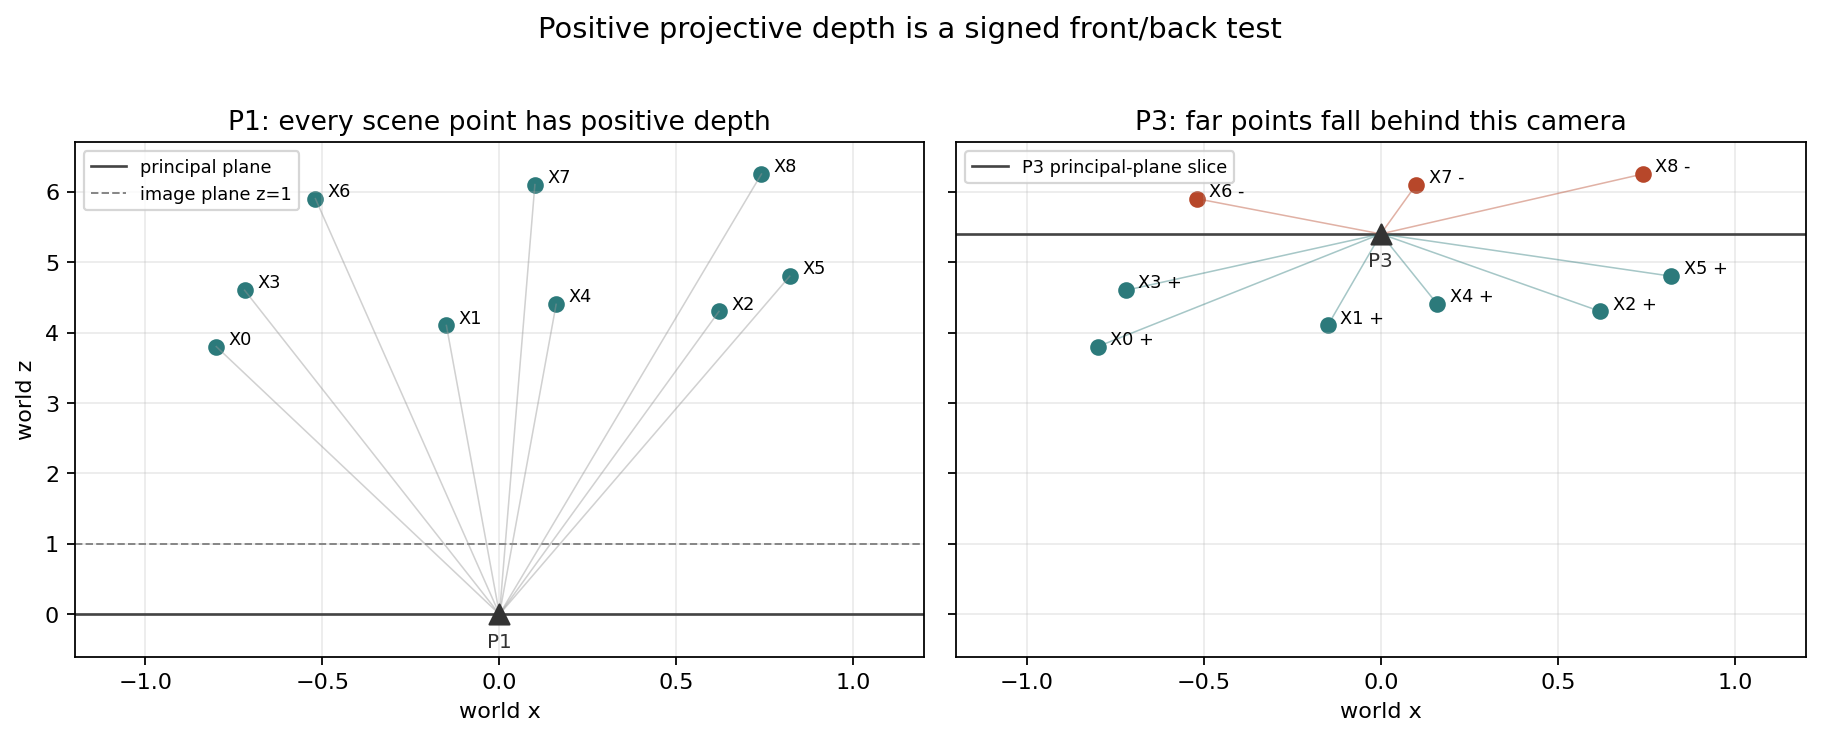

,point,depth_P1,depth_P2,depth_P3,P3_front
0,X0,3.80,4.024533,1.553570,True
1,X1,4.10,4.133406,1.241212,True
2,X2,4.30,4.104625,1.068593,True
3,X3,4.60,4.746653,0.881179,True
4,X4,4.40,4.306202,1.088321,True
5,X5,4.80,4.513384,0.651020,True
6,X6,5.90,5.956546,-0.496485,False
7,X7,6.10,5.956546,-0.601700,False
8,X8,6.25,5.941131,-0.851587,False


In [3]:
P1 = np.hstack([np.eye(3), np.zeros((3, 1))])
P2 = make_camera(center=np.array([1.35, 0.15, 0.25]), target=np.array([0.05, 0.0, 4.7]))
P3 = make_camera(center=np.array([0.0, -0.2, 5.4]), target=np.array([0.0, 0.0, 4.2]))
points3 = np.array([
    [-0.80, -0.35, 3.8], [-0.15, -0.45, 4.1], [0.62, -0.30, 4.3],
    [-0.72, 0.36, 4.6], [0.16, 0.42, 4.4], [0.82, 0.16, 4.8],
    [-0.52, -0.22, 5.9], [0.10, 0.34, 6.1], [0.74, -0.28, 6.25],
], dtype=float)
Xh = homogenize(points3)
centers = np.vstack([camera_center(P1), camera_center(P2), camera_center(P3)])
centers_from_cofactors = np.vstack([cofactor_camera_center(P) for P in [P1, P2, P3]])

depths = pd.DataFrame({
    "point": [f"X{i}" for i in range(len(Xh))],
    "depth_P1": [signed_depth(P1, X) for X in Xh],
    "depth_P2": [signed_depth(P2, X) for X in Xh],
    "depth_P3": [signed_depth(P3, X) for X in Xh],
})
depths["P3_front"] = depths["depth_P3"] > 0
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), sharey=True)
front_color, back_color = "#2C7A7B", "#B7472A"
ax = axes[0]
ax.axhline(0, color="#444444", lw=1.2, label="principal plane")
ax.axhline(1, color="#888888", lw=0.9, ls="--", label="image plane z=1")
draw_camera_marker(ax, 0.0, 0.0, "P1")
for idx, (x, _, z) in enumerate(points3):
    ax.plot([0, x], [0, z], color="#999999", lw=0.7, alpha=0.45)
    ax.scatter(x, z, color=front_color, s=42)
    ax.text(x + 0.035, z + 0.035, f"X{idx}", fontsize=8)
ax.set_title("P1: every scene point has positive depth")
ax.set_xlabel("world x"); ax.set_ylabel("world z")
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-0.6, 6.7); ax.legend(loc="upper left", fontsize=8)
ax = axes[1]
C3 = centers[2]
ax.axhline(C3[2], color="#444444", lw=1.2, label="P3 principal-plane slice")
draw_camera_marker(ax, C3[0], C3[2], "P3")
for idx, (x, _, z) in enumerate(points3):
    is_front = bool(depths.loc[idx, "P3_front"])
    color = front_color if is_front else back_color
    ax.plot([C3[0], x], [C3[2], z], color=color, lw=0.7, alpha=0.42)
    ax.scatter(x, z, color=color, s=42)
    ax.text(x + 0.035, z + 0.035, f"X{idx} {'+' if is_front else '-'}", fontsize=8)
ax.set_title("P3: far points fall behind this camera")
ax.set_xlabel("world x"); ax.set_xlim(-1.2, 1.2); ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Positive projective depth is a signed front/back test", y=1.02, fontsize=13)
fig.tight_layout()
positive_depth_path = save_matplotlib(fig, TOPIC, "figures", "positive-depth-camera-rays.png")
plt.close(fig); artifact_paths.append(positive_depth_path)
display_artifact(positive_depth_path, width=920)
depth_table_path = save_csv(depths.to_dict("records"), TOPIC, "tables", "depth-sign-products.csv")
artifact_paths.append(depth_table_path)
depths

## Quasi-Affine Means The Convex Hull Avoids The Plane Sent To Infinity

For a projective map `H`, the last homogeneous coordinate of `H X` is a scalar denominator. If that scalar changes sign on the convex hull of the input points, some segment in the hull crosses the plane mapped to infinity. That is the computational content of the quasi-affine condition.

Inspection target: the left transformation keeps all denominator signs positive; the right transformation has both signs, so the finite convex hull is split by the line sent to infinity.

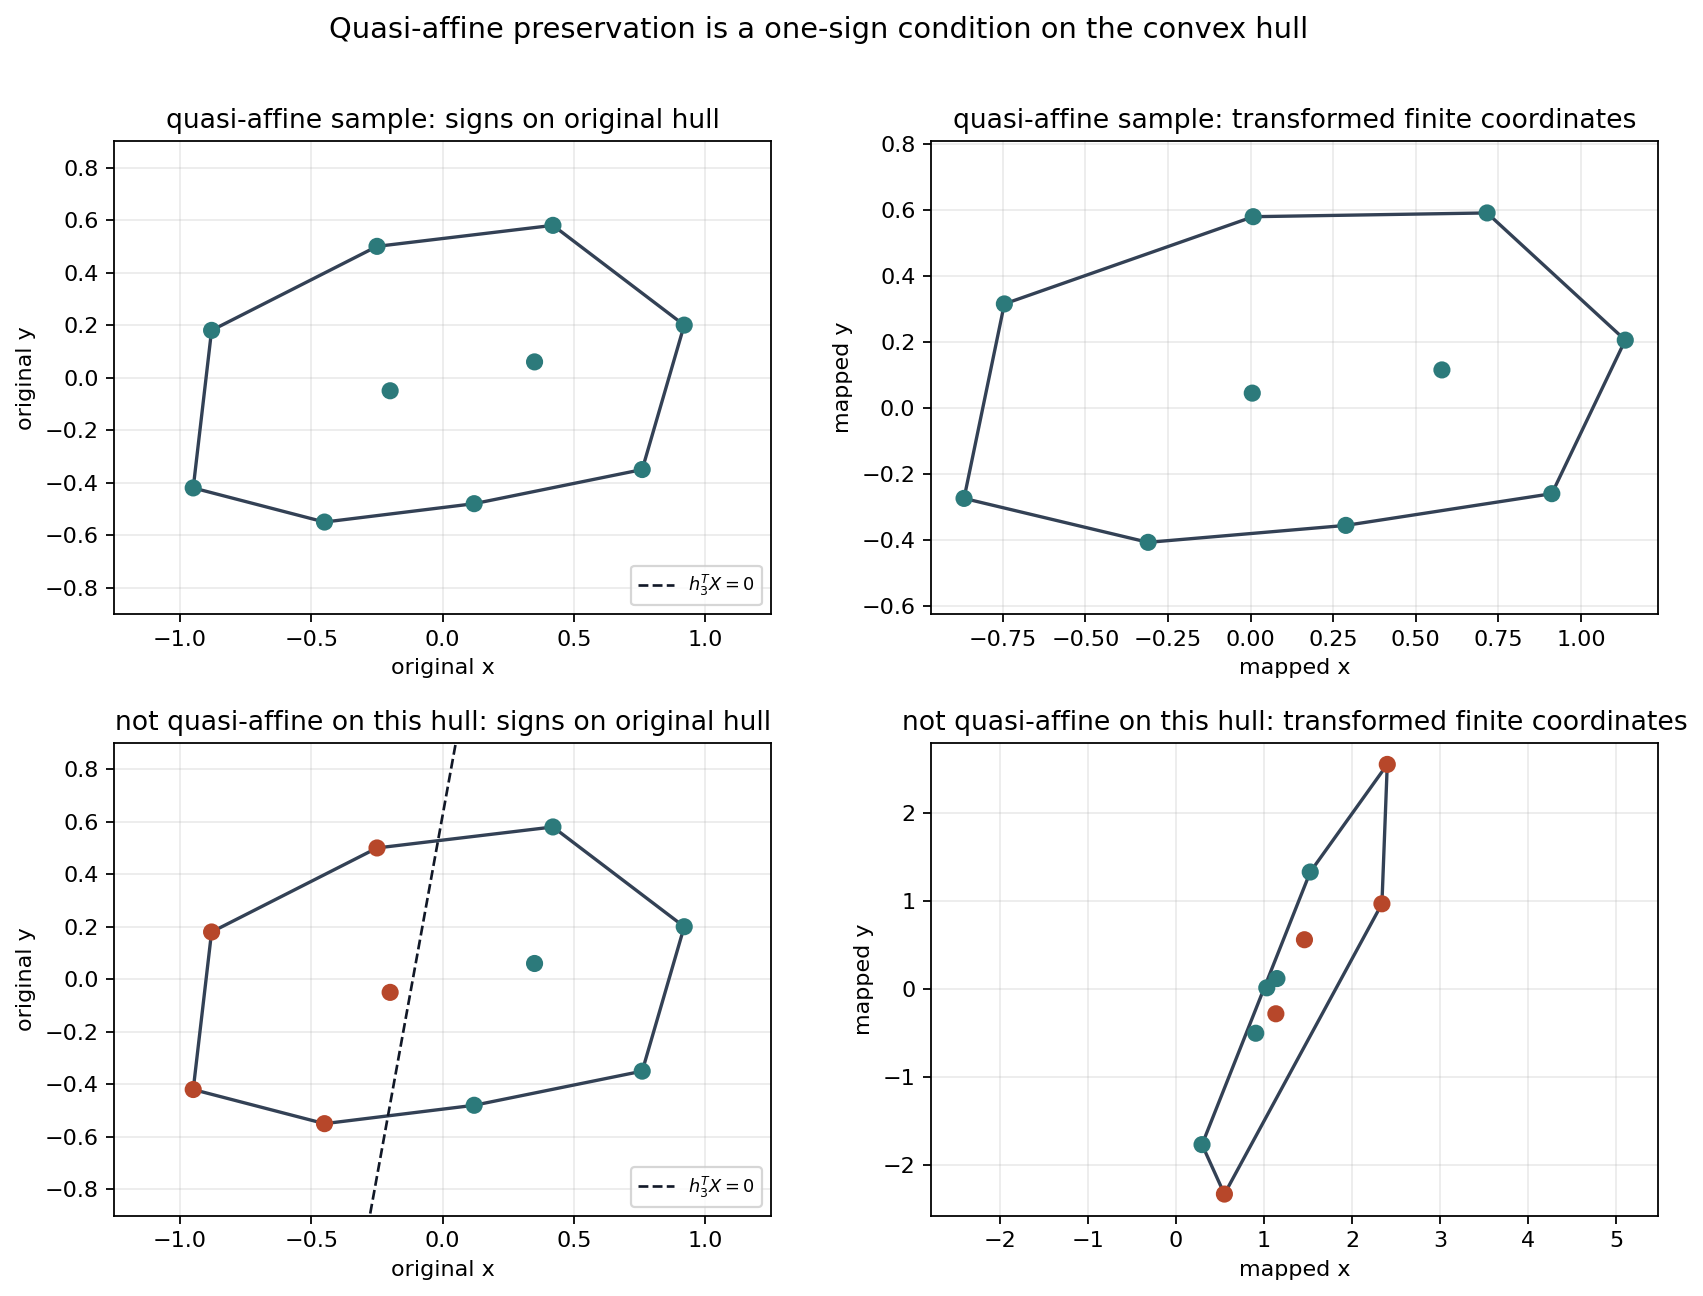

,point,good_denominator,bad_denominator,bad_sign
0,q0,0.9450,-0.6688,-1
1,q1,0.9915,-0.2080,-1
2,q2,1.0336,0.2824,1
3,q3,1.0783,0.8248,1
4,q4,1.0636,0.8776,1
5,q5,1.0046,0.3768,1
6,q6,0.9550,-0.2000,-1
7,q7,0.9206,-0.7032,-1
8,q8,0.9865,-0.0680,-1
9,q9,1.0250,0.3984,1


In [4]:
points2 = np.array([
    [-0.95, -0.42], [-0.45, -0.55], [0.12, -0.48], [0.76, -0.35],
    [0.92, 0.20], [0.42, 0.58], [-0.25, 0.50], [-0.88, 0.18],
    [-0.20, -0.05], [0.35, 0.06],
], dtype=float)
X2h = homogenize(points2)
H_good = np.array([[1.05, 0.10, 0.22], [-0.05, 0.92, 0.08], [0.08, -0.05, 1.00]])
H_bad = np.array([[1.00, 0.18, 0.05], [-0.06, 0.96, -0.03], [0.88, -0.16, 0.10]])

def map_points_2d(H, Xh):
    mapped = (H @ Xh.T).T
    return mapped, dehomogenize(mapped)

mapped_good_h, mapped_good = map_points_2d(H_good, X2h)
mapped_bad_h, mapped_bad = map_points_2d(H_bad, X2h)
scale_good = mapped_good_h[:, 2]
scale_bad = mapped_bad_h[:, 2]
fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.0))
for title, H, scales, mapped, ax0, ax1 in [
    ("quasi-affine sample", H_good, scale_good, mapped_good, axes[0, 0], axes[0, 1]),
    ("not quasi-affine on this hull", H_bad, scale_bad, mapped_bad, axes[1, 0], axes[1, 1]),
]:
    poly = hull_polygon(points2); closed = np.vstack([poly, poly[0]])
    ax0.plot(closed[:, 0], closed[:, 1], color="#334155", lw=1.5)
    colors = np.where(scales > 0, "#2C7A7B", "#B7472A")
    ax0.scatter(points2[:, 0], points2[:, 1], c=colors, s=45, zorder=3)
    xs = np.linspace(-1.15, 1.15, 200)
    if abs(H[2, 1]) > 1e-9:
        ys = -(H[2, 0] * xs + H[2, 2]) / H[2, 1]
        ax0.plot(xs, ys, color="#111827", ls="--", lw=1.2, label=r"$h_3^T X = 0$")
    elif abs(H[2, 0]) > 1e-9:
        ax0.axvline(-H[2, 2] / H[2, 0], color="#111827", ls="--", lw=1.2, label=r"$h_3^T X = 0$")
    ax0.set_title(title + ": signs on original hull")
    ax0.set_aspect("equal", adjustable="box"); ax0.set_xlim(-1.25, 1.25); ax0.set_ylim(-0.9, 0.9)
    ax0.legend(fontsize=8, loc="lower right")
    finite = np.all(np.isfinite(mapped), axis=1) & (np.linalg.norm(mapped, axis=1) < 30)
    if finite.sum() >= 3:
        poly_m = hull_polygon(mapped[finite]); closed_m = np.vstack([poly_m, poly_m[0]])
        ax1.plot(closed_m[:, 0], closed_m[:, 1], color="#334155", lw=1.5)
    ax1.scatter(mapped[:, 0], mapped[:, 1], c=colors, s=45, zorder=3)
    ax1.set_title(title + ": transformed finite coordinates")
    ax1.set_aspect("equal", adjustable="datalim"); ax1.set_xlabel("mapped x"); ax1.set_ylabel("mapped y")
axes[0, 0].set_ylabel("original y"); axes[1, 0].set_ylabel("original y")
for ax in axes[:, 0]: ax.set_xlabel("original x")
fig.suptitle("Quasi-affine preservation is a one-sign condition on the convex hull", y=1.01, fontsize=13)
fig.tight_layout()
qa_path = save_matplotlib(fig, TOPIC, "figures", "quasi-affine-convex-hull-signs.png")
plt.close(fig); artifact_paths.append(qa_path)
display_artifact(qa_path, width=920)
check_data["quasi_affine_good_all_same_sign"] = bool(np.all(scale_good > 0) or np.all(scale_good < 0))
check_data["quasi_affine_bad_has_mixed_signs"] = bool(np.any(scale_bad > 0) and np.any(scale_bad < 0))
pd.DataFrame({"point":[f"q{i}" for i in range(len(points2))], "good_denominator":scale_good, "bad_denominator":scale_bad, "bad_sign":sign_label(scale_bad)})

## Cheiral Inequalities As Feasible Reconstruction Cells

After representative signs have been fixed so each observed image equation has positive scale, a plane-at-infinity vector `v` must satisfy the cheiral inequalities `X_i^T v > 0` for reconstructed points and `delta C_j^T v > 0` for camera centers. The scalar `delta` is the orientation sign of the projective transform.

The LP below maximizes a common margin `d`, turning strict inequalities into `a^T v >= d`. A positive `d` is a numerical certificate that this side assignment is feasible.

Inspection target: when all cameras are separable from all points, the `delta = -1` cell is also feasible; when a camera is interleaved with the points, that opposite-orientation cell disappears.

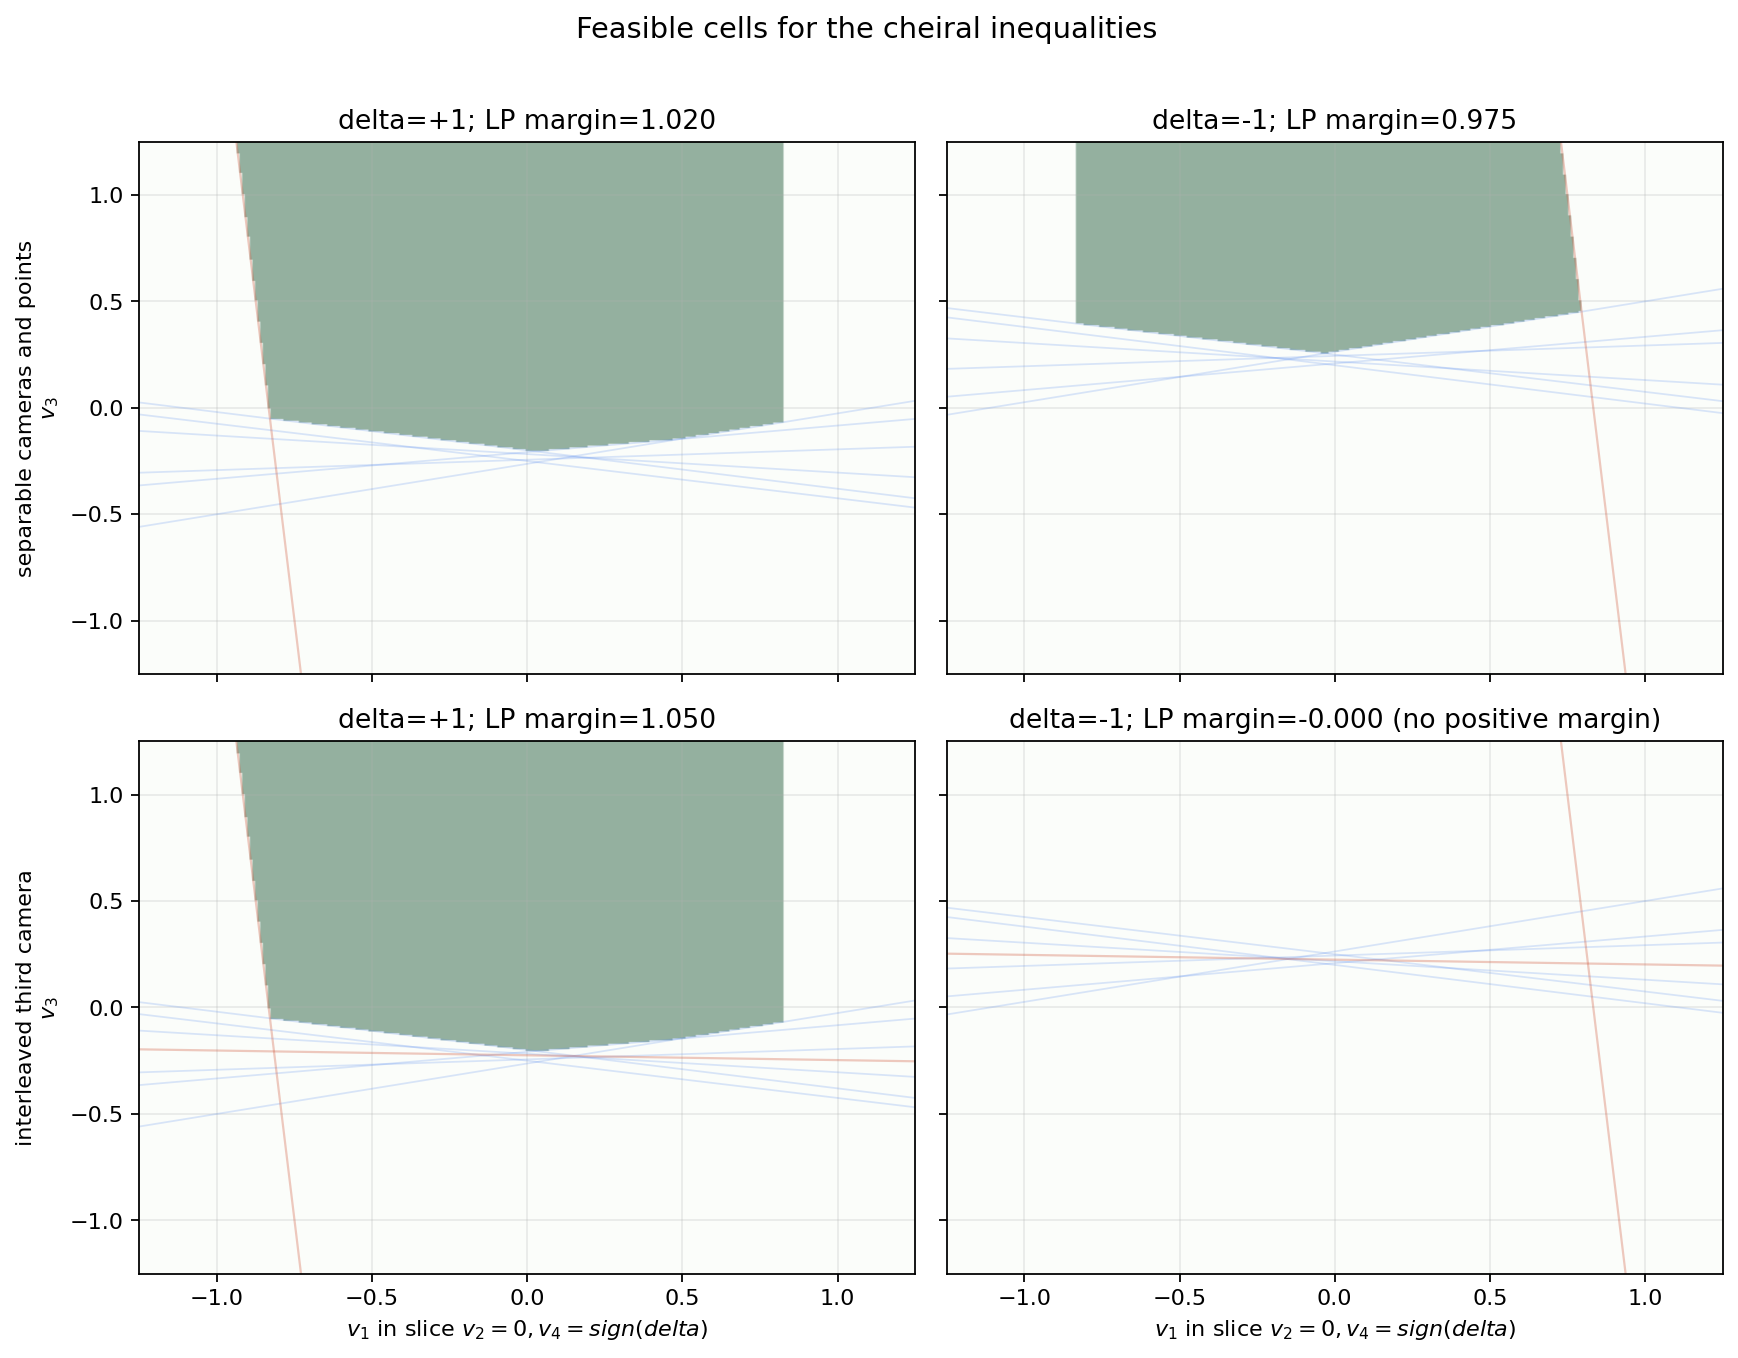

,scenario,delta,success,margin,min_margin,v
0,separable cameras and points,1,True,1.020000,1.020000,"[-0.01667, 1.0, 0.4, 1.0]"
1,separable cameras and points,-1,True,0.975418,0.975418,"[-0.02048, -0.44384, 0.49164, -1.0]"
2,interleaved third camera,1,True,1.050000,1.050000,"[-0.04167, -1.0, 1.0, 1.0]"
3,interleaved third camera,-1,False,-0.000000,0.000000,"[-0.0, -0.0, -0.0, -0.0]"


In [5]:
points_sep = homogenize(np.array([
    [-0.9, -0.2, 3.8], [-0.2, 0.1, 4.1], [0.7, -0.1, 4.0],
    [-0.6, 0.4, 4.8], [0.4, 0.3, 4.6], [0.9, -0.3, 5.0],
], dtype=float))
centers_sep = homogenize(np.array([[-1.2, 0.0, 0.0], [1.2, 0.0, 0.1], [0.0, 0.1, -0.2]], dtype=float))
centers_interleaved = homogenize(np.array([[-1.2, 0.0, 0.0], [1.2, 0.0, 0.1], [0.1, 0.0, 4.45]], dtype=float))
lp_cases = []
for scenario_name, pts, cams in [("separable cameras and points", points_sep, centers_sep), ("interleaved third camera", points_sep, centers_interleaved)]:
    for delta in [1, -1]:
        result = solve_cheiral_lp(pts, cams, delta)
        lp_cases.append({"scenario": scenario_name, "delta": delta, "success": result["success"], "margin": result["margin"], "min_margin": result.get("min_margin", float("nan")), "v": None if result["v"] is None else np.round(result["v"], 5).tolist()})
lp_frame = pd.DataFrame(lp_cases)
lp_path = save_csv(lp_frame.to_dict("records"), TOPIC, "tables", "cheiral-lp-margins.csv")
artifact_paths.append(lp_path)

v1 = np.linspace(-1.25, 1.25, 301); v3 = np.linspace(-1.25, 1.25, 301)
V1, V3 = np.meshgrid(v1, v3)
fig, axes = plt.subplots(2, 2, figsize=(11, 8.4), sharex=True, sharey=True)
for row, (scenario_name, pts, cams) in enumerate([("separable cameras and points", points_sep, centers_sep), ("interleaved third camera", points_sep, centers_interleaved)]):
    for col, delta in enumerate([1, -1]):
        ax = axes[row, col]
        mask = feasible_mask_on_slice(pts, cams, delta, V1, V3)
        ax.imshow(mask.astype(float), origin="lower", extent=[v1.min(), v1.max(), v3.min(), v3.max()], cmap="Greens", alpha=0.42, aspect="auto")
        plot_halfspace_lines(ax, pts, cams, delta)
        row_lp = lp_frame[(lp_frame["scenario"] == scenario_name) & (lp_frame["delta"] == delta)].iloc[0]
        title = f"delta={delta:+d}; LP margin={row_lp['margin']:.3f}"
        if not bool(row_lp["success"]): title += " (no positive margin)"
        ax.set_title(title); ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
        if col == 0: ax.set_ylabel(scenario_name + "/n$v_3$")
        if row == 1: ax.set_xlabel("$v_1$ in slice $v_2=0, v_4=sign(delta)$")
fig.suptitle("Feasible cells for the cheiral inequalities", y=1.01, fontsize=13)
fig.tight_layout()
cells_path = save_matplotlib(fig, TOPIC, "figures", "cheiral-inequality-feasible-cells.png")
plt.close(fig); artifact_paths.append(cells_path)
display_artifact(cells_path, width=920)
check_data["cheiral_lp"] = lp_cases
lp_frame

In [6]:
neg_solution = solve_cheiral_lp(points_sep, centers_sep, -1)
v_sep = neg_solution["v"]
xx = np.linspace(-1.5, 1.5, 20); yy = np.linspace(-0.8, 0.8, 20)
XX, YY = np.meshgrid(xx, yy)
ZZ = -(v_sep[0] * XX + v_sep[1] * YY + v_sep[3]) / v_sep[2]
fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(x=points_sep[:,0], y=points_sep[:,1], z=points_sep[:,2], mode="markers+text", text=[f"X{i}" for i in range(len(points_sep))], marker=dict(size=5, color="#2C7A7B"), name="points"))
fig3d.add_trace(go.Scatter3d(x=centers_sep[:,0], y=centers_sep[:,1], z=centers_sep[:,2], mode="markers+text", text=[f"C{j+1}" for j in range(len(centers_sep))], marker=dict(size=7, color="#B7472A", symbol="diamond"), name="camera centers"))
fig3d.add_trace(go.Surface(x=XX, y=YY, z=ZZ, opacity=0.42, showscale=False, colorscale=[[0,"#F6C85F"],[1,"#F6C85F"]], name="v^T X = 0"))
fig3d.update_layout(title="Plane-at-infinity candidate separating cameras from points", scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"), margin=dict(l=0,r=0,t=50,b=0))
html_path = save_plotly_html(fig3d, TOPIC, "interactive", "cheiral-halfspace-scene.html")
artifact_paths.append(html_path)
display_artifact(html_path, width=860, height=560)
check_data["separating_plane_v_delta_minus"] = np.round(v_sep, 8).tolist()

## Sign Ambiguities And Opposite Orientation

There are two related sign problems in the chapter. First, homogeneous representatives of cameras and points can be multiplied by `-1`; the observable image point is unchanged, but the scalar `w_ij` changes. Second, after the representatives have been made consistent, there may still be two strong realizations with opposite orientation. The second ambiguity occurs exactly when a plane separates all camera centers from all visible points.

Inspection target: the same point set admits an opposite-orientation cell when all cameras sit on one side, but the cell vanishes when a third camera lies among the points.

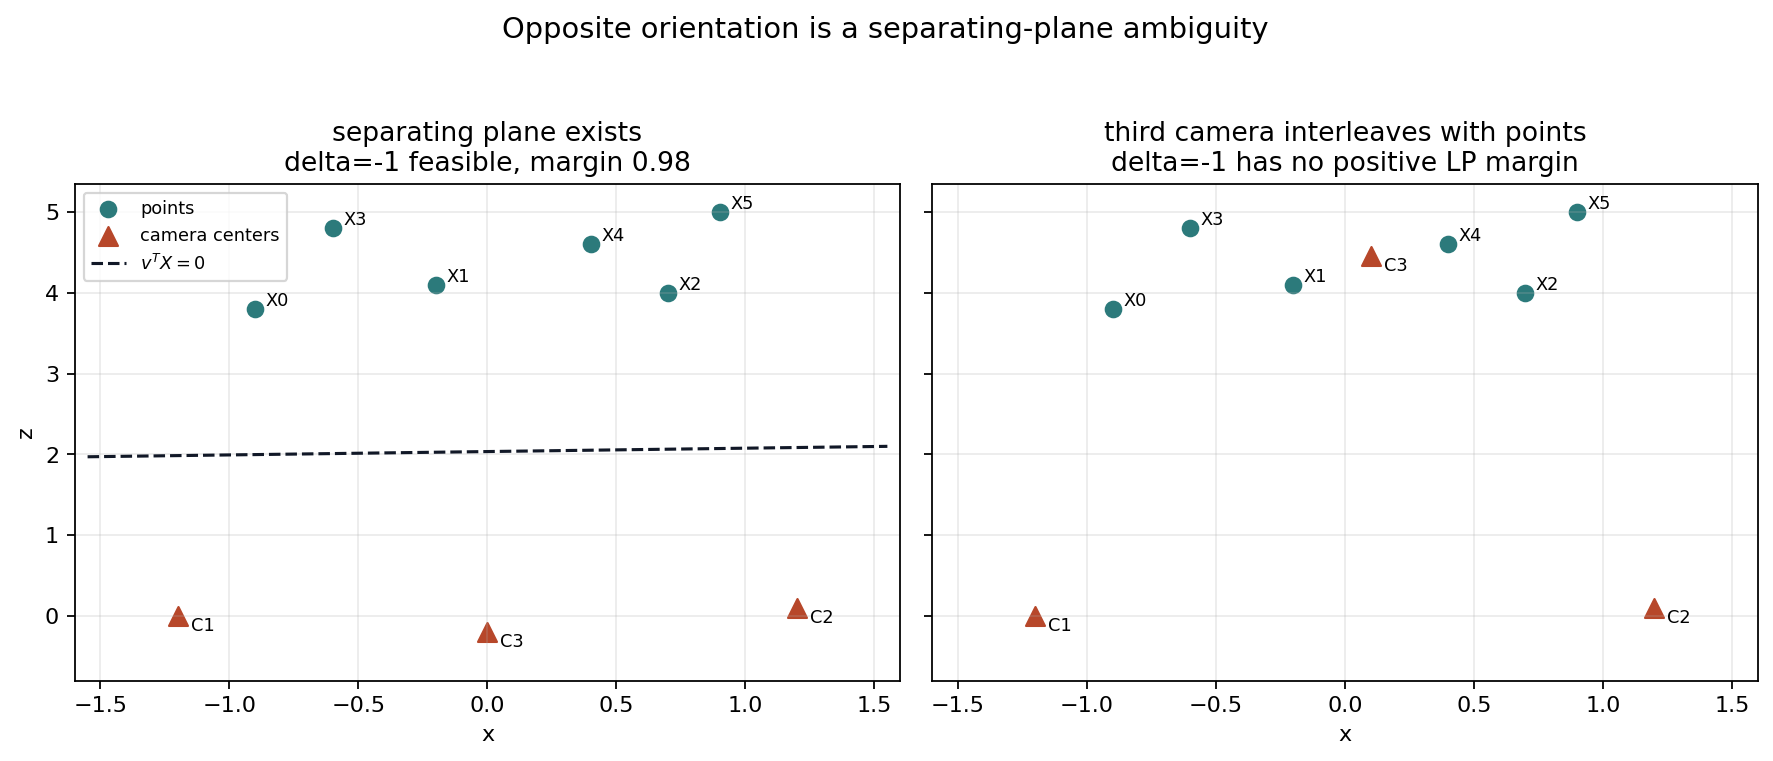

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), sharey=True)
for ax, title, cams, lp_delta_minus in [
    (axes[0], "separating plane exists", centers_sep, solve_cheiral_lp(points_sep, centers_sep, -1)),
    (axes[1], "third camera interleaves with points", centers_interleaved, solve_cheiral_lp(points_sep, centers_interleaved, -1)),
]:
    ax.scatter(points_sep[:, 0], points_sep[:, 2], s=48, color="#2C7A7B", label="points")
    ax.scatter(cams[:, 0], cams[:, 2], s=72, marker="^", color="#B7472A", label="camera centers")
    for i, pnt in enumerate(points_sep): ax.text(pnt[0] + 0.04, pnt[2] + 0.04, f"X{i}", fontsize=8)
    for j, c in enumerate(cams): ax.text(c[0] + 0.05, c[2] - 0.18, f"C{j+1}", fontsize=8)
    if lp_delta_minus["success"]:
        v = lp_delta_minus["v"]; xs = np.linspace(-1.55, 1.55, 200); zs = -(v[0] * xs + v[3]) / v[2]
        ax.plot(xs, zs, color="#111827", lw=1.4, ls="--", label=r"$v^T X=0$")
        subtitle = f"delta=-1 feasible, margin {lp_delta_minus['margin']:.2f}"
    else:
        subtitle = "delta=-1 has no positive LP margin"
    ax.set_title(title + "/n" + subtitle); ax.set_xlabel("x"); ax.set_xlim(-1.6, 1.6); ax.set_ylim(-0.8, 5.35)
axes[0].set_ylabel("z"); axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Opposite orientation is a separating-plane ambiguity", y=1.03, fontsize=13)
fig.tight_layout()
ambiguity_path = save_matplotlib(fig, TOPIC, "figures", "opposite-orientation-sign-ambiguity.png")
plt.close(fig); artifact_paths.append(ambiguity_path)
display_artifact(ambiguity_path, width=920)
check_data["delta_minus_feasible_when_separable"] = bool(solve_cheiral_lp(points_sep, centers_sep, -1)["success"])
check_data["delta_minus_infeasible_when_interleaved"] = bool(not solve_cheiral_lp(points_sep, centers_interleaved, -1)["success"])

## Third-View Visibility And Depth Ordering

A two-view projective reconstruction does not by itself tell us which points a new third camera should see. Once one point is known to be visible in that third view, the sign of `w_1 w_3` for that anchor fixes the classification for the other points.

Depth ordering is a separate question. For two points on the same camera ray, inverse depth `chi = 1/depth` decreases along the ray in a chosen orientation. If the strong realization might have the opposite orientation, the comparison of `chi` must be reversed.

Inspection target: the sign-product classifier agrees with direct positive-depth evaluation for `P3`, while the ray diagram shows why orientation is needed before deciding which point occludes the other.

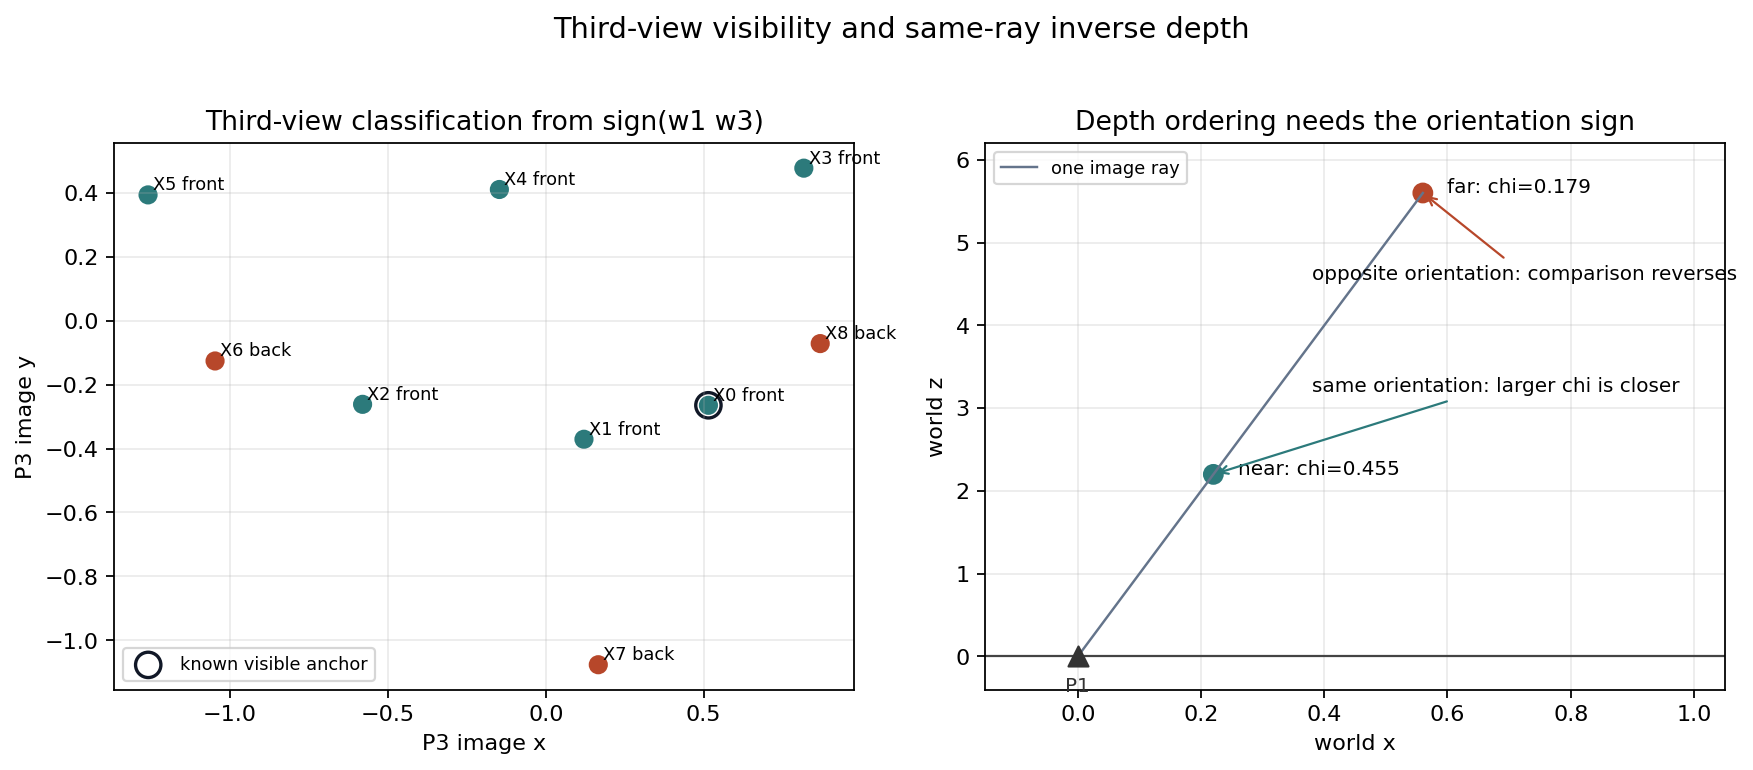

,point,w1,w3,sign_w1_w3,predicted_front_P3,direct_depth_P3,direct_front_P3
0,X0,3.80,1.553570,1,True,1.553570,True
1,X1,4.10,1.241212,1,True,1.241212,True
2,X2,4.30,1.068593,1,True,1.068593,True
3,X3,4.60,0.881179,1,True,0.881179,True
4,X4,4.40,1.088321,1,True,1.088321,True
5,X5,4.80,0.651020,1,True,0.651020,True
6,X6,5.90,-0.496485,-1,False,-0.496485,False
7,X7,6.10,-0.601700,-1,False,-0.601700,False
8,X8,6.25,-0.851587,-1,False,-0.851587,False


In [8]:
w1 = np.array([image_scale(P1, X) for X in Xh])
w3 = np.array([image_scale(P3, X) for X in Xh])
product_sign = sign_label(w1 * w3)
direct_p3_front = depth_signs(P3, Xh) > 0
anchor_index = int(np.flatnonzero(direct_p3_front)[0])
anchor_sign = product_sign[anchor_index]
predicted_p3_front = product_sign == anchor_sign
third_view_rows = []
for i, X in enumerate(Xh):
    third_view_rows.append({"point": f"X{i}", "w1": float(w1[i]), "w3": float(w3[i]), "sign_w1_w3": int(product_sign[i]), "predicted_front_P3": bool(predicted_p3_front[i]), "direct_depth_P3": float(signed_depth(P3, X)), "direct_front_P3": bool(direct_p3_front[i])})
third_view_frame = pd.DataFrame(third_view_rows)
third_view_path = save_csv(third_view_frame.to_dict("records"), TOPIC, "tables", "third-view-visibility-sign-products.csv")
artifact_paths.append(third_view_path)
near = np.array([0.22, 0.10, 2.2, 1.0]); far = np.array([0.56, 0.2545454545454545, 5.6, 1.0])
near_image = (P1 @ near)[:2] / (P1 @ near)[2]
far_image = (P1 @ far)[:2] / (P1 @ far)[2]
chi_near = 1.0 / signed_depth(P1, near); chi_far = 1.0 / signed_depth(P1, far)
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.7))
ax = axes[0]
colors = np.where(predicted_p3_front, "#2C7A7B", "#B7472A")
proj3 = project_points(P3, points3)
ax.scatter(proj3[:, 0], proj3[:, 1], c=colors, s=58)
for i, pnt in enumerate(proj3):
    ax.text(pnt[0] + 0.015, pnt[1] + 0.015, f"X{i} {'front' if predicted_p3_front[i] else 'back'}", fontsize=8)
ax.scatter(proj3[anchor_index, 0], proj3[anchor_index, 1], s=130, facecolors="none", edgecolors="#111827", lw=1.5, label="known visible anchor")
ax.set_title("Third-view classification from sign(w1 w3)"); ax.set_xlabel("P3 image x"); ax.set_ylabel("P3 image y"); ax.legend(fontsize=8)
ax = axes[1]
ax.axhline(0, color="#444444", lw=1.0); draw_camera_marker(ax, 0.0, 0.0, "P1")
ax.plot([0, far[0]], [0, far[2]], color="#64748B", lw=1.1, label="one image ray")
ax.scatter([near[0], far[0]], [near[2], far[2]], color=["#2C7A7B", "#B7472A"], s=70)
ax.text(near[0] + 0.04, near[2], f"near: chi={chi_near:.3f}", fontsize=9)
ax.text(far[0] + 0.04, far[2], f"far: chi={chi_far:.3f}", fontsize=9)
ax.annotate("same orientation: larger chi is closer", xy=(near[0], near[2]), xytext=(0.38, 3.2), arrowprops=dict(arrowstyle="->", color="#2C7A7B"), fontsize=9)
ax.annotate("opposite orientation: comparison reverses", xy=(far[0], far[2]), xytext=(0.38, 4.55), arrowprops=dict(arrowstyle="->", color="#B7472A"), fontsize=9)
ax.set_xlim(-0.15, 1.05); ax.set_ylim(-0.4, 6.2); ax.set_xlabel("world x"); ax.set_ylabel("world z"); ax.set_title("Depth ordering needs the orientation sign"); ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Third-view visibility and same-ray inverse depth", y=1.02, fontsize=13); fig.tight_layout()
third_view_figure_path = save_matplotlib(fig, TOPIC, "figures", "third-view-visibility-depth-order.png")
plt.close(fig); artifact_paths.append(third_view_figure_path)
display_artifact(third_view_figure_path, width=920)
check_data["third_view_anchor_index"] = anchor_index
check_data["third_view_sign_product_matches_depth"] = bool(np.array_equal(predicted_p3_front, direct_p3_front))
check_data["inverse_depth_near_greater_than_far"] = bool(chi_near > chi_far)
third_view_frame

## Applied Lab: Move The Third Camera Through The Scene

This lab varies only one design choice: the third camera center's `z` coordinate. The point cloud and the first two cameras stay fixed. For each camera position, the code counts which points would be in front of that camera and tests whether the opposite-orientation cheiral cell remains feasible when that camera center is included.

In [9]:
sweep_rows = []
for zc in np.linspace(-0.4, 5.2, 15):
    P_sweep = make_camera(center=np.array([0.05, -0.15, zc]), target=np.array([0.0, 0.0, 4.4]))
    C_sweep = camera_center(P_sweep)
    front_count = int((depth_signs(P_sweep, Xh) > 0).sum())
    cams = np.vstack([centers_sep[:2], C_sweep])
    lp_neg = solve_cheiral_lp(points_sep, cams, -1)
    sweep_rows.append({"third_camera_z": float(zc), "points_in_front_of_third_camera": front_count, "delta_minus_feasible": bool(lp_neg["success"]), "delta_minus_margin": float(lp_neg["margin"])})
sweep_frame = pd.DataFrame(sweep_rows)
sweep_path = save_csv(sweep_frame.to_dict("records"), TOPIC, "tables", "third-camera-z-sweep.csv")
artifact_paths.append(sweep_path)
sweep_frame

,third_camera_z,points_in_front_of_third_camera,delta_minus_feasible,delta_minus_margin
0,-0.4,9,True,0.975418
1,0.0,9,True,0.974728
2,0.4,9,True,0.933453
3,0.8,9,True,0.765737
4,1.2,9,True,0.616157
5,1.6,9,True,0.488309
6,2.0,9,True,0.377778
7,2.4,9,True,0.281269
8,2.8,9,True,0.196272
9,3.2,9,True,0.120844


## Final Sanity Checks

The checks below are deliberately geometric rather than only syntactic. They assert scale invariance of depth signs, the camera-center cofactor formula, the transformation law for cheirality, LP feasibility/infeasibility for the intended configurations, third-view classification, inverse-depth ordering, and artifact integrity.

In [10]:
assert np.allclose(centers, centers_from_cofactors, atol=1e-8)
for P, C in zip([P1, P2, P3], centers_from_cofactors):
    assert np.linalg.norm(P @ C) < 1e-8

for X in Xh[:4]:
    assert np.sign(signed_depth(P2, X)) == np.sign(signed_depth(-2.0 * P2, -3.0 * X))

v_test = np.array([0.08, -0.03, 0.12, 1.0])
H_test = np.array([[1.0,0.0,0.0,0.0],[0.0,1.0,0.0,0.0],[0.0,0.0,1.0,0.0],v_test])
delta_test = np.sign(np.linalg.det(H_test))
P2_transformed = P2 @ np.linalg.inv(H_test)
C2 = np.array([((-1) ** (j + 1)) * np.linalg.det(np.delete(P2, j, axis=1)) for j in range(4)])
for X in Xh:
    transformed_depth_sign = np.sign(signed_depth(P2_transformed, H_test @ X))
    predicted_sign = np.sign(image_scale(P2, X) * (v_test @ X) * (v_test @ C2) * delta_test)
    assert transformed_depth_sign == predicted_sign

assert check_data["quasi_affine_good_all_same_sign"]
assert check_data["quasi_affine_bad_has_mixed_signs"]
lp_lookup = {(row["scenario"], row["delta"]): row for row in check_data["cheiral_lp"]}
assert lp_lookup[("separable cameras and points", 1)]["success"]
assert lp_lookup[("separable cameras and points", -1)]["success"]
assert lp_lookup[("interleaved third camera", 1)]["success"]
assert not lp_lookup[("interleaved third camera", -1)]["success"]
assert check_data["delta_minus_feasible_when_separable"]
assert check_data["delta_minus_infeasible_when_interleaved"]
assert check_data["third_view_sign_product_matches_depth"]
assert check_data["inverse_depth_near_greater_than_far"]
assert np.linalg.norm(near_image - far_image) < 1e-12
assert_artifacts(artifact_paths, min_bytes=256)
for path in artifact_paths:
    assert str(path.resolve()).startswith(str((BOOK_ROOT / "artifacts" / TOPIC).resolve()))

summary = {
    "source_span": "PDF pages 533-550; printed pages 515-532",
    "artifact_count_before_summary": len(artifact_paths),
    "artifacts_before_summary": [relative_to_book(path, BOOK_ROOT) for path in artifact_paths],
    "camera_center_max_residual": float(max(np.linalg.norm(P @ C) for P, C in zip([P1, P2, P3], centers_from_cofactors))),
    "depth_signs_P1_all_positive": bool(np.all(depth_signs(P1, Xh) > 0)),
    "depth_signs_P2_all_positive": bool(np.all(depth_signs(P2, Xh) > 0)),
    "depth_signs_P3_front_count": int(np.sum(direct_p3_front)),
    "quasi_affine_good_all_same_sign": check_data["quasi_affine_good_all_same_sign"],
    "quasi_affine_bad_has_mixed_signs": check_data["quasi_affine_bad_has_mixed_signs"],
    "cheiral_lp_cases": check_data["cheiral_lp"],
    "third_view_anchor_index": check_data["third_view_anchor_index"],
    "third_view_sign_product_matches_depth": check_data["third_view_sign_product_matches_depth"],
    "inverse_depth_near": float(chi_near),
    "inverse_depth_far": float(chi_far),
}
final_sanity = summary
summary_path = save_json(summary, TOPIC, "checks", "cheirality-invariants.json")
artifact_paths.append(summary_path)
assert_artifacts([summary_path], min_bytes=256)
display_artifact(summary_path)
summary

`artifacts/chapter-21/checks/cheirality-invariants.json`

{'source_span': 'PDF pages 533-550; printed pages 515-532',
 'artifact_count_before_summary': 10,
 'artifacts_before_summary': ['artifacts/chapter-21/figures/positive-depth-camera-rays.png',
  'artifacts/chapter-21/tables/depth-sign-products.csv',
  'artifacts/chapter-21/figures/quasi-affine-convex-hull-signs.png',
  'artifacts/chapter-21/tables/cheiral-lp-margins.csv',
  'artifacts/chapter-21/figures/cheiral-inequality-feasible-cells.png',
  'artifacts/chapter-21/interactive/cheiral-halfspace-scene.html',
  'artifacts/chapter-21/figures/opposite-orientation-sign-ambiguity.png',
  'artifacts/chapter-21/tables/third-view-visibility-sign-products.csv',
  'artifacts/chapter-21/figures/third-view-visibility-depth-order.png',
  'artifacts/chapter-21/tables/third-camera-z-sweep.csv'],
 'camera_center_max_residual': 2.6193750069204537e-16,
 'depth_signs_P1_all_positive': True,
 'depth_signs_P2_all_positive': True,
 'depth_signs_P3_front_count': 6,
 'quasi_affine_good_all_same_sign': True,
 'q

## Takeaways

Cheirality is the part of projective reconstruction that remembers which side of a camera and which side of a candidate plane-at-infinity the scene occupies. The checks in this notebook make that memory explicit: depth signs survive homogeneous rescaling, quasi-affine maps keep one denominator sign on the convex hull, and the cheiral inequalities turn the front/back requirement into a linear feasibility problem.

The practical warning is that reprojection alone is not enough. A reconstruction can be algebraically consistent and still have the wrong orientation, an ambiguous third-view visibility classification, or an unresolved depth ordering. The fix is to carry the sign information alongside the projective equations and to test the feasible cells before interpreting the reconstruction as a visible 3D scene.